2.7.1+cu128
True
NVIDIA GeForce RTX 5060 Laptop GPU


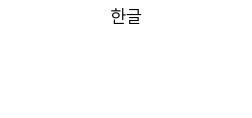

In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib import rcParams
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

print(torch.__version__)
print(torch.cuda.is_available())     
print(torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize = (3, 1))
plt.title("한글")
plt.axis("off")
plt.show()

In [2]:
# Chapter 4
# 가중치 초기화 함수

import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(nn.Linear(1, 2),
                                   nn.Sigmoid())
        self.fc = nn.Linear(2, 1)
        self._init_weights()
    def _init_weights(self):
        nn.init.xavier_uniform_(self.layer[0].weight)
        # layer가 층이 깊어지면 기울기가 증폭될 수 있음, 기울기를 초기화 함 xavier_uniform
        self.layer[0].bias.data.fill_(0.01)

        nn.init.xavier_uniform_(self.fc.weight)
        self.fc.bias.data.fill_(0.01)

model = Net().to(device)

In [3]:
for name, param in model.named_parameters():
    print(name, param.data)

layer.0.weight tensor([[-1.3091],
        [ 0.7833]], device='cuda:0')
layer.0.bias tensor([0.0100, 0.0100], device='cuda:0')
fc.weight tensor([[-0.9532,  0.7878]], device='cuda:0')
fc.bias tensor([0.0100], device='cuda:0')


In [4]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(nn.Linear(1, 2),
                                   nn.Sigmoid())
        self.fc = nn.Linear(2, 1)
        self.apply(self._init_weights)
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.constant_(module.bias, 0.01)
        print(module)
model = Net().to(device)

Linear(in_features=1, out_features=2, bias=True)
Sigmoid()
Sequential(
  (0): Linear(in_features=1, out_features=2, bias=True)
  (1): Sigmoid()
)
Linear(in_features=2, out_features=1, bias=True)
Net(
  (layer): Sequential(
    (0): Linear(in_features=1, out_features=2, bias=True)
    (1): Sigmoid()
  )
  (fc): Linear(in_features=2, out_features=1, bias=True)
)


In [5]:
for name, param in model.named_parameters():
    print(name, param.data)

layer.0.weight tensor([[0.2499],
        [0.5742]], device='cuda:0')
layer.0.bias tensor([0.0100, 0.0100], device='cuda:0')
fc.weight tensor([[ 0.7152, -0.2956]], device='cuda:0')
fc.bias tensor([0.0100], device='cuda:0')


In [6]:
# L1, L2규제

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
x_data = torch.rand(256, 1) * 10
y_data = 2 * x_data + 1 + torch.randn(256, 1) * 0.5

train_dataset = TensorDataset(x_data, y_data)
train_dataloader = DataLoader(train_dataset,
                              batch_size = 32,
                              shuffle = True,
                              drop_last = True)

model = nn.Linear(1, 1).to(device)
criterion = nn.MSELoss().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.0001)

In [ ]:
for epoch in range(10):
    for x, y in train_dataloader:
        x = x.to(device)
        y = y.to(device)

        output = model(x)
        _lambda = 0.5
        # l1_loss = sum(p.abs().sum() for p in model.parameters())
        l2_loss = sum(p.pow(2.0).sum() for p in model.parameters())

        # loss = criterion(output, y) + _lambda * l1_loss # lambda 값은 고정값 새로운 상수 더하는
        loss = criterion(output, y) + _lambda * l2_loss # 실제로 l1보다 l2를 많이씀

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(epoch + 1, loss.item(), l2_loss.item())

1 43.63859939575195 1.6317267417907715
2 37.38126754760742 1.7424918413162231
3 35.363136291503906 1.852604866027832
4 24.483177185058594 1.9659628868103027
5 25.473344802856445 2.0726816654205322
6 17.778522491455078 2.183267831802368
7 23.316627502441406 2.2836503982543945
8 23.486549377441406 2.38447642326355
9 17.047584533691406 2.4897093772888184
10 18.339136123657227 2.5847792625427246


In [8]:
print(model.weight.item(), model.bias.item())

1.064867615699768 -0.6346111297607422


In [ ]:
# # 가중치 감쇠 적용 optimizer사용
# model = nn.Linear(1, 1).to(device)
# optimizer = torch.optim.SGD(model.parameters(), lr = 0.01, weight_decay = 0.01) # 가중치 감쇠 적용 > Over Fit 적용

In [ ]:
# Dropout 적용 / Dropout layer 생성하여 층을 지나가게하면됨

In [10]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
x_data = torch.rand(256, 1) * 10
y_data = 2 * x_data + 1 + torch.randn(256, 1) * 0.5

train_dataset = TensorDataset(x_data, y_data)
train_dataloader = DataLoader(train_dataset,
                              batch_size = 32,
                              shuffle = True,
                              drop_last = True)

model = nn.Linear(1, 1).to(device)
criterion = nn.MSELoss().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.0001)

In [ ]:
for epoch in range(20):
    for x, y in train_dataloader:
        x = x.to(device)
        y = y.to(device)

        output = model(x)
        loss = criterion(output, y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1) # 기울기 Clipping 을 적용하는 한줄
        optimizer.step()
    print(epoch, loss.item())

In [11]:
# 텍스트 데이터 증강
import nltk

In [13]:
for resource in ["wordnet",
                 "omw-1.4",
                 "averaged_perceptron_tagger",
                 "averaged_perceptron_tagger_eng"]:
    nltk.download(resource, quiet = True)

In [ ]:
import nlpaug.augmenter.word as naw # word

texts = ["Those who can imagine anything, can create the possible.",
         "We can only see a short distance ahead, but we can see plenty there that needs to be done",
         "If a machine is expected to be infallible, it cannot also be intelligent"]
aug = naw.ContextualWordEmbsAug(model_path = "bert-base-uncased", # 문맥에 맞게 쓰는
                                action = "insert",
                                device = "cpu")
augmented_texts = aug.augment(texts)

for text, augmented in zip(texts, augmented_texts):
    print(text)
    print(augmented)

c:\Users\KDT-17\Documents\17-NLP & CV\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Those who can imagine anything, can create the possible.
but those who hope can imagine creating anything, can create the highest possible.
We can only see a short distance ahead, but we can see plenty there that needs to be done
we originally can only vaguely see a passing short distance ahead, but soon we can see some plenty there that needs to quickly be done
If a machine is expected to be infallible, it cannot also be intelligent
or if a machine f is expected to be merely infallible, and it cannot necessarily also be intelligent


In [ ]:
import nlpaug.augmenter.char as nac

texts = ["Those who can imagine anything, can create the possible.",
         "We can only see a short distance ahead, but we can see plenty there that needs to be done",
         "If a machine is expected to be infallible, it cannot also be intelligent"]

aug = nac.RandomCharAug(action = "delete") #랜덤캐릭터
augmented_texts = aug.augment(texts)

for text, augmented in zip(texts, augmented_texts):
    print(text)
    print(augmented)

Those who can imagine anything, can create the possible.
Ths who can imae nyhng, can crat the possible.
We can only see a short distance ahead, but we can see plenty there that needs to be done
We can oy see a sor dstnc ead, but we can see pety the that needs to be done
If a machine is expected to be infallible, it cannot also be intelligent
If a mhie is expected to be inaible, it cnno as be ntllige


In [16]:
import nlpaug.augmenter.word as naw

texts = ["Those who can imagine anything, can create the possible.",
         "We can only see a short distance ahead, but we can see plenty there that needs to be done",
         "If a machine is expected to be infallible, it cannot also be intelligent"]

aug = naw.RandomWordAug(action = "swap")
augmented_texts = aug.augment(texts)

for text, augmented in zip(texts, augmented_texts):
    print(text)
    print(augmented)

Those who can imagine anything, can create the possible.
Who imagine those can anything, create can the possible.
We can only see a short distance ahead, but we can see plenty there that needs to be done
Can we only see a distance ahead short but, we can see plenty that there needs be to done
If a machine is expected to be infallible, it cannot also be intelligent
A if is machine to expected infallible be, it cannot also intelligent be


In [17]:
import nlpaug.augmenter.word as naw

texts = ["Those who can imagine anything, can create the possible.",
         "We can only see a short distance ahead, but we can see plenty there that needs to be done",
         "If a machine is expected to be infallible, it cannot also be intelligent"]

aug = naw.SynonymAug(aug_src = "wordnet")
augmented_texts = aug.augment(texts)

for text, augmented in zip(texts, augmented_texts):
    print(text)
    print(augmented)

Those who can imagine anything, can create the possible.
Those world health organization send away suppose anything, can create the possible.
We can only see a short distance ahead, but we can see plenty there that needs to be done
We lavatory only visit a short distance ahead, but we can see plenty in that respect that demand to cost done
If a machine is expected to be infallible, it cannot also be intelligent
If a machine is expected to live infallible, it cannot as well represent well informed


In [18]:
import nlpaug.augmenter.word as naw

texts = ["Those who can imagine anything, can create the possible.",
         "We can only see a short distance ahead, but we can see plenty there that needs to be done",
         "If a machine is expected to be infallible, it cannot also be intelligent"]

reserved_tokens = [["can", "can't", "cannot", "could"]]

reserved_aug = naw.ReservedAug(reserved_tokens = reserved_tokens)
# aug = naw.SynonymAug(aug_src = "wordnet")
augmented_texts = reserved_aug.augment(texts)

for text, augmented in zip(texts, augmented_texts):
    print(text)
    print(augmented)

Those who can imagine anything, can create the possible.
Those who can't imagine anything, can't create the possible.
We can only see a short distance ahead, but we can see plenty there that needs to be done
We cannot only see a short distance ahead, but we can't see plenty there that needs to be done
If a machine is expected to be infallible, it cannot also be intelligent
If a machine is expected to be infallible, it can also be intelligent


In [19]:
# 텍스트 증강 > facebook에서 사용하는 역번역 backtranslate

import nlpaug.augmenter.word as naw

texts = ["Those who can imagine anything, can create the possible.",
         "We can only see a short distance ahead, but we can see plenty there that needs to be done",
         "If a machine is expected to be infallible, it cannot also be intelligent"]

back_translation = naw.BackTranslationAug(from_model_name = "facebook/wmt19-en-de",
                                          to_model_name = "facebook/wmt19-de-en",
                                          device = "cpu")

augmented_texts = back_translation.augment(texts)

for text, augmented in zip(texts, augmented_texts):
    print(text)
    print(augmented)

config.json:   0%|          | 0.00/825 [00:00<?, ?B/s]

c:\Users\KDT-17\Documents\17-NLP & CV\.venv\Lib\site-packages\huggingface_hub\file_download.py:159: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\KDT-17\.cache\huggingface\hub\models--facebook--wmt19-en-de. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/235 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/825 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

vocab-src.json: 0.00B [00:00, ?B/s]

vocab-tgt.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Those who can imagine anything, can create the possible.
Whoever can imagine everything, can create the possible.
We can only see a short distance ahead, but we can see plenty there that needs to be done
We can only look a little ahead, but we can see a lot there that needs to be done.
If a machine is expected to be infallible, it cannot also be intelligent
If a machine is expected to be infallible, it cannot be intelligent either
